In [1]:
import pandas as pd             # data package
import matplotlib.pyplot as plt # graphics 
import datetime as dt
import numpy as np
from census import Census # This is new...
from scipy.stats.mstats import gmean

import matplotlib.ticker as mtick 

import requests, io             # internet and input tools  
import zipfile as zf            # zip file tools 
import os  

#import weightedcalcs as wc
#import numpy as np

import pyarrow as pa
import pyarrow.parquet as pq

In [2]:
my_key = "&key=34e40301bda77077e24c859c6c6c0b721ad73fc7"
# This is my key. I'm nice and I have it posted. If you will be doing more with this
# please get your own key!

In [3]:
def get_hs10_data(year, country_code):

    end_use = "hs?get=CON_VAL_YR,CTY_NAME,CAL_DUT_YR,I_COMMODITY_SDESC,CON_QY1_YR,UNIT_QY1,CON_QY1_YR_FLAG" 

    url = "https://api.census.gov/data/timeseries/intltrade/imports/" + end_use 
    url = url + my_key + "&time=" + year + "-" + "12" + "&COMM_LVL=HS10" + "&I_COMMODITY=*" + "&CTY_CODE=" + country_code


    r = requests.get(url) 
    
    print(r)
    
    df = pd.DataFrame(r.json()[1:]) # This then converts it to a dataframe
    # Note that the first entry is the labels

    df.columns = r.json()[0]

    df.time = pd.to_datetime(df.time, format="%Y-%m")

    df["CON_VAL_YR"] = df["CON_VAL_YR"].astype(float)

    df["CON_QY1_YR"] = df["CON_QY1_YR"].astype(float)

    df["CAL_DUT_YR"] = df["CAL_DUT_YR"].astype(float)

    df["tariff"] = 100*df["CAL_DUT_YR"] / df["CON_VAL_YR"]

    df["price"] = df.CON_VAL_YR / df.CON_QY1_YR

    df["price_tariff"] = df["price"] * (1 + df["tariff"]/100)

    df["price"] = df["price"].replace([np.inf, -np.inf], np.nan)

    df["price_tariff"] = df["price_tariff"].replace([np.inf, -np.inf], np.nan)

    df["HS6"] = df["I_COMMODITY"].str[0:6]

    df["HS4"] = df["I_COMMODITY"].str[0:4]

    df["HS2"] = df["I_COMMODITY"].str[0:2]

    return df

In [4]:
def get_hs10_data_month(year, month, country_code):

    end_use = "hs?get=CON_VAL_MO,CTY_NAME,CAL_DUT_MO,I_COMMODITY,I_COMMODITY_SDESC" 

    url = "https://api.census.gov/data/timeseries/intltrade/imports/" + end_use 
    
    if country_code == "":
        url = url + my_key + "&time=" + year + "-" + month + "&COMM_LVL=HS10" 
    else:
        url = url + my_key + "&time=" + year + "-" + month + "&COMM_LVL=HS10" + "&CTY_CODE=" + country_code

    r = requests.get(url) 
    
    print(r)
    
    df = pd.DataFrame(r.json()[1:]) # This then converts it to a dataframe
    # Note that the first entry is the labels

    df.columns = r.json()[0]

    df.time = pd.to_datetime(df.time, format="%Y-%m")

    df["CON_VAL_MO"] = df["CON_VAL_MO"].astype(float)

    # df["CON_QY1_MO"] = df["CON_QY1_MO"].astype(float)

    df["CAL_DUT_MO"] = df["CAL_DUT_MO"].astype(float)

    df["applied_tariff"] = 100*df["CAL_DUT_MO"] / df["CON_VAL_MO"]

    # df["price"] = df.CON_VAL_MO / df.CON_QY1_MO

    # df["price_tariff"] = df["price"] * (1 + df["tariff"]/100)

    # df["price"] = df["price"].replace([np.inf, -np.inf], np.nan)

    # df["price_tariff"] = df["price_tariff"].replace([np.inf, -np.inf], np.nan)

    df["HS8"] = df["I_COMMODITY"].str[0:8]

    df["HS6"] = df["I_COMMODITY"].str[0:6]

    df["HS4"] = df["I_COMMODITY"].str[0:4]

    df["HS2"] = df["I_COMMODITY"].str[0:2]

    df["HS10"] = df["I_COMMODITY"]

    return df

In [26]:
country_list.set_index("CTY_CODE", inplace = True)

In [28]:
country_list.loc["4120"].tariff

10.0

In [19]:
country = "5700"

month = "08"

df = get_hs10_data_month("2025", month , country)
# first get the data for the month and country

print( df["CAL_DUT_MO"].sum() / df["CON_VAL_MO"].sum() * 100)

print(df["applied_tariff"].mean())

print(df["applied_tariff"].median())




<Response [200]>
39.722928990714216
51.19165150835718
54.999649385003195


In [52]:
country = "0003"

month = "02"

df = get_hs10_data_month("2025", month , country)
# first get the data for the month and country

print( df["CAL_DUT_MO"].sum() / df["CON_VAL_MO"].sum() * 100)

print(df["applied_tariff"].mean())

print(df["applied_tariff"].median())

<Response [200]>
1.0106763906692149
4.4708849875995735
2.753637287908713


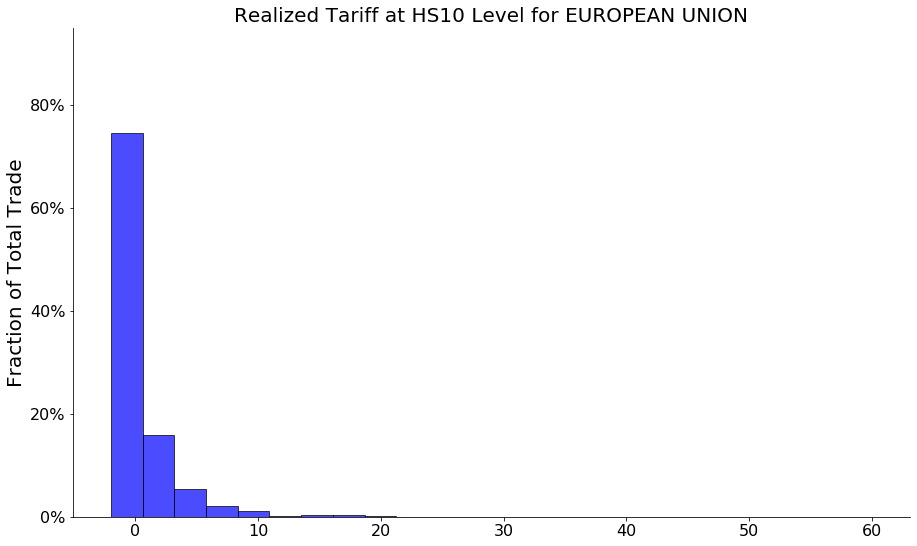

In [53]:
fig, ax = plt.subplots(figsize = (15,9))

bin_edges = np.linspace(-2, 60, 25)  # 50 bins

# Digitize delta_tariff into bins
bin_indices = np.digitize(df["applied_tariff"], bin_edges) - 1

# Sum CON_VAL_MAY in each bin
bin_sums = np.zeros(len(bin_edges) - 1)
for i in range(len(bin_sums)):
    bin_sums[i] = df.loc[bin_indices == i, "CON_VAL_MO"].sum()

# Convert to fraction of total CON_VAL_MAY
fractions = bin_sums / df["CON_VAL_MO"].sum()

ax.bar(bin_edges[:-1], fractions, width=np.diff(bin_edges), align='edge', color='blue', alpha=0.7, edgecolor='black')

ax.set_ylim(top=0.95)

ax.set_ylabel("Fraction of Total Trade", fontsize = 20)

# ax.set_xlabel("Change in HS10 Tariff: May 2025 - May 2024", fontsize = 20)

ax.set_title("Realized Tariff at HS10 Level for " + df["CTY_NAME"].iloc[0], fontsize = 20)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

ax.tick_params(axis='x', labelsize=16)  # Change font size of x-axis tick labels
ax.tick_params(axis='y', labelsize=16)  # Change font size of y-axis tick labels

ax.spines["right"].set_visible(False)

ax.spines["top"].set_visible(False)

plt.show()

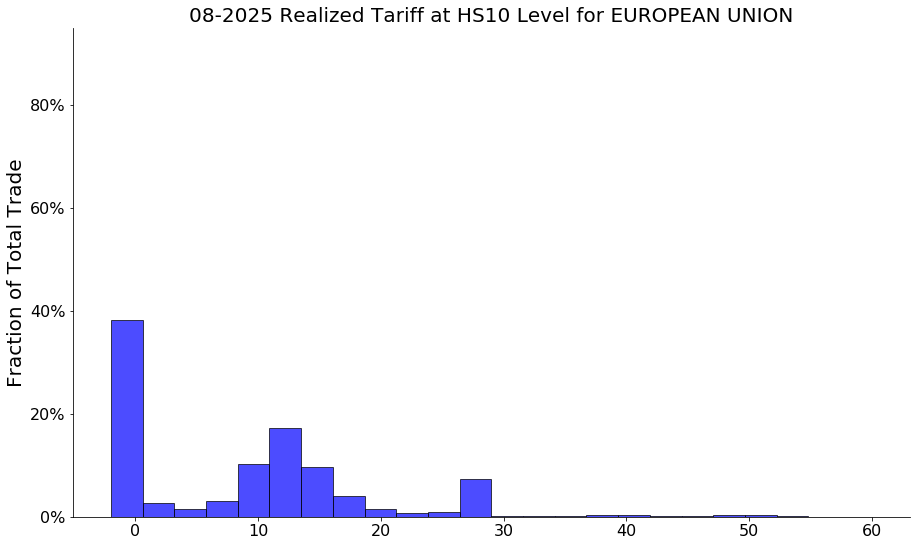

In [51]:
fig, ax = plt.subplots(figsize = (15,9))

bin_edges = np.linspace(-2, 60, 25)  # 50 bins

# Digitize delta_tariff into bins
bin_indices = np.digitize(df["applied_tariff"], bin_edges) - 1

# Sum CON_VAL_MAY in each bin
bin_sums = np.zeros(len(bin_edges) - 1)
for i in range(len(bin_sums)):
    bin_sums[i] = df.loc[bin_indices == i, "CON_VAL_MO"].sum()

# Convert to fraction of total CON_VAL_MAY
fractions = bin_sums / df["CON_VAL_MO"].sum()

ax.bar(bin_edges[:-1], fractions, width=np.diff(bin_edges), align='edge', color='blue', alpha=0.7, edgecolor='black')

ax.set_ylim(top=0.95)

ax.set_ylabel("Fraction of Total Trade", fontsize = 20)

# ax.set_xlabel("Change in HS10 Tariff: May 2025 - May 2024", fontsize = 20)

ax.set_title("08-2025 Realized Tariff at HS10 Level for " + df["CTY_NAME"].iloc[0], fontsize = 20)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

ax.tick_params(axis='x', labelsize=16)  # Change font size of x-axis tick labels
ax.tick_params(axis='y', labelsize=16)  # Change font size of y-axis tick labels

ax.spines["right"].set_visible(False)

ax.spines["top"].set_visible(False)

plt.show()

In [75]:
foo = df[df["HS2"]  == "30"]

foo[foo["delta_predic_tariff"] > 0.0].sort_values("I_COMMODITY")

,I_COMMODITY,applied_tariff,tariff,CON_VAL_MO,I_COMMODITY_SDESC,time,CTY_NAME,HS2,applied_tariff_2024,CON_VAL_2024,delta_applied_tariff,delta_predic_tariff
11308,3001900150,0.000000,10.0,146873.0,"OTHER GLANDS AND ORGANS, DRIED ETC",2025-05-01,EUROPEAN UNION,30,0.000000,556463.0,0.000000,10.0
11309,3001900190,0.006386,10.0,10006357.0,HEPARIN AND ITS SALTS; OTHER HUMAN OR ANIMAL S...,2025-05-01,EUROPEAN UNION,30,0.000000,7538138.0,0.006386,10.0
11310,3002120010,0.000000,10.0,3131608.0,HUMAN BLOOD PLASMA,2025-05-01,EUROPEAN UNION,30,0.000000,24498654.0,0.000000,10.0
2100,3002120020,0.131807,10.0,1590966.0,"NORMAL HUMAN BLOOD SERA, INCLUDING FREEZE-DRIED",2025-05-01,EUROPEAN UNION,30,0.000000,1281644.0,0.131807,10.0
11311,3002120030,0.000000,10.0,404514.0,HUMAN IMMUNE BLOOD SERA,2025-05-01,EUROPEAN UNION,30,0.000000,188635.0,0.000000,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2444,3006100100,8.779141,10.0,37163829.0,"STERILE SURGICAL CATGUT, SIMILAR STERILE MATER...",2025-05-01,EUROPEAN UNION,30,0.000000,37163713.0,8.779141,10.0
11192,3006400000,9.985585,10.0,25398662.0,DENTAL CEMENTS AND OTHER DENTAL FILLINGS ETC,2025-05-01,EUROPEAN UNION,30,0.000000,32653528.0,9.985585,10.0
2447,3006500000,10.004264,10.0,18762.0,FIRST-AID BOXES AND KITS,2025-05-01,EUROPEAN UNION,30,0.000000,53454.0,10.004264,10.0
2449,3006910000,0.018846,10.0,7142008.0,APPLIANCES IDENTIFIABLE FOR OSTOMY USE,2025-05-01,EUROPEAN UNION,30,0.039467,9065817.0,-0.020621,10.0


In [ ]:
foo

,I_COMMODITY,applied_tariff,tariff,CON_VAL_MO,I_COMMODITY_SDESC,time,CTY_NAME,HS2,applied_tariff_2024,CON_VAL_2024,delta_applied_tariff,delta_predic_tariff
0,0101210010,3.975665,10.0,2489898.0,"HORSES, LIVE, PUREBRED BREEDING MALE",2025-05-01,EUROPEAN UNION,01,0.0,2344690.0,3.975665,10.0
1,0101210020,10.000026,10.0,756408.0,"HORSES, LIVE, PUREBRED BREEDING FEMALE",2025-05-01,EUROPEAN UNION,01,0.0,2914481.0,10.000026,10.0
2,0101290090,9.352150,10.0,27010378.0,"HORSES, LIVE, NESOI",2025-05-01,EUROPEAN UNION,01,0.0,22674634.0,9.352150,10.0
3,0106199120,9.999825,10.0,800824.0,"DOGS, LIVE",2025-05-01,EUROPEAN UNION,01,0.0,1732288.0,9.999825,10.0
4,0106199195,9.999817,10.0,273275.0,"MAMMALS, LIVE, NESOI",2025-05-01,EUROPEAN UNION,01,0.0,135082.0,9.999817,10.0


In [ ]:
# country = "4120"

# month = "05"

# dfmay = get_hs10_data_month("2025", month , country)

# print( dfmay["CAL_DUT_MO"].sum() / dfmay["CON_VAL_MO"].sum() * 100)

# print(dfmay["tariff"].median())

# df = get_hs10_data_month("2024", month , country)

# print( df["CAL_DUT_MO"].sum() / df["CON_VAL_MO"].sum() * 100)

# print(df["tariff"].median())

# dfmay.rename(columns={"CON_VAL_MO": "CON_VAL_MAY", "tariff": "tariff_MAY"}, inplace=True)

# df = pd.merge(dfmay[["I_COMMODITY", "tariff_MAY", "CON_VAL_MAY"]], 
#               df[["I_COMMODITY", "tariff", "CON_VAL_MO"]], how="inner", on=["I_COMMODITY"])

# df["delta_tariff"] = df["tariff_MAY"] - df["tariff"]

<Response [200]>
6.871199317834926
11.598546970118683
<Response [200]>
0.9559805314254074
2.499949808267582


In [123]:
dfmay["CTY_NAME"].iloc[0]

'UNITED KINGDOM'

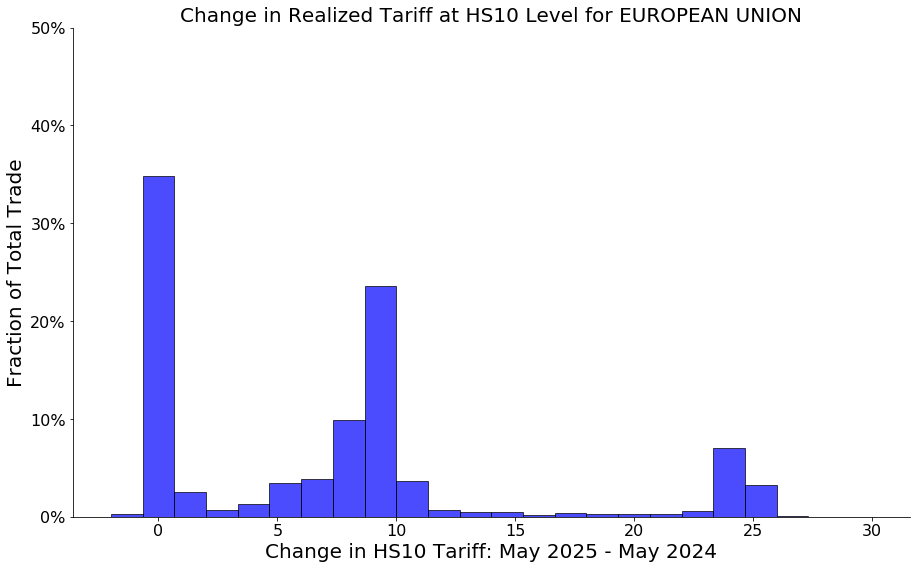

In [37]:
fig, ax = plt.subplots(figsize = (15,9))

bin_edges = np.linspace(-2, 30, 25)  # 50 bins


# Digitize delta_tariff into bins
bin_indices = np.digitize(df["delta_applied_tariff"], bin_edges) - 1

# Sum CON_VAL_MAY in each bin
bin_sums = np.zeros(len(bin_edges) - 1)
for i in range(len(bin_sums)):
    bin_sums[i] = df.loc[bin_indices == i, "CON_VAL_2024"].sum()

# Convert to fraction of total CON_VAL_MAY
fractions = bin_sums / df["CON_VAL_2024"].sum()

ax.bar(bin_edges[:-1], fractions, width=np.diff(bin_edges), align='edge', color='blue', alpha=0.7, edgecolor='black')

ax.set_ylim(top=0.50)

ax.set_ylabel("Fraction of Total Trade", fontsize = 20)

ax.set_ylabel("Fraction of Total Trade", fontsize = 20)

ax.set_xlabel("Change in HS10 Tariff: May 2025 - May 2024", fontsize = 20)

ax.set_title("Change in Realized Tariff at HS10 Level for " + df["CTY_NAME"].iloc[0], fontsize = 20)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

ax.tick_params(axis='x', labelsize=16)  # Change font size of x-axis tick labels
ax.tick_params(axis='y', labelsize=16)  # Change font size of y-axis tick labels

ax.spines["right"].set_visible(False)

ax.spines["top"].set_visible(False)

plt.show()

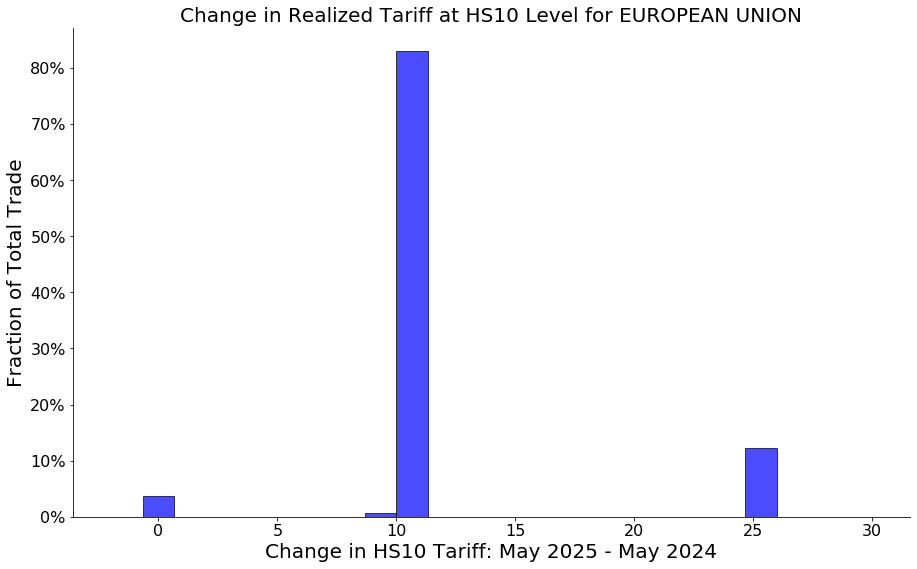

In [41]:
fig, ax = plt.subplots(figsize = (15,9))

bin_edges = np.linspace(-2, 30, 25)  # 50 bins


# Digitize delta_tariff into bins
bin_indices = np.digitize(df["delta_predic_tariff"], bin_edges) - 1

# Sum CON_VAL_MAY in each bin
bin_sums = np.zeros(len(bin_edges) - 1)
for i in range(len(bin_sums)):
    bin_sums[i] = df.loc[bin_indices == i, "CON_VAL_MO"].sum()

# Convert to fraction of total CON_VAL_MAY
fractions = bin_sums / df["CON_VAL_MO"].sum()

ax.bar(bin_edges[:-1], fractions, width=np.diff(bin_edges), align='edge', color='blue', alpha=0.7, edgecolor='black')

# ax.set_ylim(top=0.50)

ax.set_ylabel("Fraction of Total Trade", fontsize = 20)

ax.set_ylabel("Fraction of Total Trade", fontsize = 20)

ax.set_xlabel("Change in HS10 Tariff: May 2025 - May 2024", fontsize = 20)

ax.set_title("Change in Realized Tariff at HS10 Level for " + df["CTY_NAME"].iloc[0], fontsize = 20)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

ax.tick_params(axis='x', labelsize=16)  # Change font size of x-axis tick labels
ax.tick_params(axis='y', labelsize=16)  # Change font size of y-axis tick labels

ax.spines["right"].set_visible(False)

ax.spines["top"].set_visible(False)

plt.show()

In [70]:
df_positive_tolerance.sort_values(by=["CON_VAL_MAY"], ascending=False, inplace=True)

df_positive_tolerance.head(50)

c:\ProgramData\Anaconda3\lib\site-packages\pandas\util\_decorators.py:311: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return func(*args, **kwargs)


,I_COMMODITY,tariff_MAY,CON_VAL_MAY,tariff,CON_VAL_MO,delta_tariff
3542,9801001028,0.000000,359074871.0,0.000000,104883257.0,0.000000e+00
458,3002140010,0.000000,175196434.0,0.000000,6282742.0,0.000000e+00
612,3004909221,0.000000,142106974.0,0.000000,133143092.0,0.000000e+00
513,3004909234,0.000000,134107750.0,0.000000,3734623.0,0.000000e+00
3056,3004909215,0.006368,116343417.0,0.000000,489778466.0,6.368216e-03
467,3002150011,0.000000,73353249.0,0.000000,12012511.0,0.000000e+00
973,7108121013,0.000000,62813880.0,0.000000,26782353.0,0.000000e+00
3543,9801001030,0.000000,49726286.0,0.000000,59064360.0,0.000000e+00
2470,9021500000,0.001815,48694821.0,0.000000,41675681.0,1.815388e-03
468,3002150091,0.000000,40389701.0,0.000000,319736792.0,0.000000e+00
